# 5.7. Predicting House Prices on Kaggle
D2L의 Predicting House Prices on Kaggle장을 PyTorch 기준으로 정리함.

이번 장에서는 실제 Kaggle 데이터를 사용하여 집의 여러 특징으로부터
집의 판매 가격(`SalePrice`)을 예측한다.

전체 과정

원본 데이터 -> 데이터 확인 -> 결측치 처리 -> 숫자형 데이터 표준화 -> 범주형 데이터 One-Hot Encoding -> PyTorch Tensor 변환 -> 모델 학습 -> K-Fold Cross Validation -> Test 데이터 예측 -> csv 생성

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt 
import torch 
from torch import nn 
from torch.utils.data import DataLoader 
from torchvision import datasets, transforms

torch.manual_seed(42) 

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


## 1. 데이터 불러오기

Kaggle 데이터는 크게 두개로 나뉜다.

- `train.csv`: 집의 특징 + 실제 판매 가격
- `test.csv`: 집의 특징만 존재

하나의 집은 이런 특징들을 가진다.

```text
집 크기
건축 연도
지붕 종류
도로 형태
지하실 상태
차고 크기
.
.
.
```

그리고 학습데이터 정답인 `SalePrice`가 추가되어 있다.

X = 집의 여러 특징
Y = 집의 실제 판매 가격

형태의 회귀 문제이다.

In [ ]:
import pandas as pd
import torch

from torch import nn
from torch.utils.data import TensorDataset, DataLoader

train_df = pd.read_csv("./data/train.csv")
test_df = pd.read_csv("./data/test.csv")

print("train:", train_df.shape) # 80개 입력 column + SalePrice
print("test :", test_df.shape)  # 80개 입력 column

train: (1460, 81)
test : (1459, 80)


## 2. 숫자형 데이터 전처리

먼저 ID는 제거한다. 각 집을 구분하기 위한 번호이고 집값을 설명하는 의미 있는 특징이라고 보기 어렵기 때문이다.

그리고 숫자형 데이터의 크기를 맞춘다. D2L에선 다음 표준화를 쓴다.

$$
x'=\frac{x-\mu}{\sigma}
$$

숫자 feature마다 값의 범위가 크게 다를 수 있다.

위 식에서 

    μ : 해당 feature의 평균
    σ : 해당 feature의 표준편차

이다. 표준화 후에는 대략 

    평균 ≈ 0
    표준편차 ≈ 1

의 형태가 된다.

이렇게 하면 feature들의 크기 차이 때문에 학습이 불안정해지는 문제를 줄일 수 있다. 그리고 결측값 `NaN`도 존재한다.

D2L에서는 숫자 데이터를 표준화 하고 `NaN`을 0으로 채운다. 표준화 후 0은해당 feature에 평균에 해당하는 값으로 볼 수 있다.

## 3. 범주형 데이터는 One-Hot Encoding

집 데이터에 숫자가 아닌 문자열도 있다.

```text
MSZoning = RL
RoofStyle = Gable
GarageType = Attchd
```

신경망은 문자열을 그대로 입력받아 계산할 수 없다. 그래서 One-Hot Encoding이 필요하다.

예를 들어서
```text
MSZoning = RL
였다면

MSZoning_RL = 1
MSZoning_RM = 0
MSZoning_FV = 0
MSZoning_RH = 0
```
여러개의 0과 1 feature로 변환한다.

D2L에서도 `pd.get_dummies()`를 이용해서 범주형 변수를 indicator/one-hot feature로 바꾼다. 이 과정 때문에 feature 수가 크게 늘어난다.

In [ ]:
label_col = "SalePrice"

# Id와 정답 SalePrice 제거 후 train/test feature 합치기
all_features = pd.concat( # 따로 one-hot endcoding하면 column 구조가 달라질 위험
    [
        train_df.drop(columns=["Id", label_col]),
        test_df.drop(columns=["Id"])
    ],
    axis=0
)

# 숫자형 column 찾기
numeric_cols = all_features.select_dtypes(
    exclude="object"
).columns

# 숫자형 feature 표준화
all_features[numeric_cols] = (
    all_features[numeric_cols] - all_features[numeric_cols].mean()
) / all_features[numeric_cols].std()

# 숫자형 결측값 처리
all_features[numeric_cols] = (
    all_features[numeric_cols].fillna(0)
)

# 문자열 범주형 feature를 One-Hot Encoding
all_features = pd.get_dummies(
    all_features,
    dummy_na=True
)

# PyTorch에서 사용하기 쉽게 float32로 변환
all_features = all_features.astype("float32")

print(all_features.shape)

(2919, 330)


## 4. 집값에 log를 왜 사용하나

D2L은 SalePrice를 그대로 학습하지 않고 로그를 씌운다.

집값은 절대적인 오차보다 상대적인 오차가 중요한 경우가 많다.

예를 들어서
```text
실제 가격: 2억
예측 가격: 3억

오차 = 1억(50% 정도 큰 오차)

실제 가격: 20억
예측 가격: 21억

오차 = 1억(5% 정도 작은 오차)
```

집값에서는 단순한 가격 차이보다 비율 차이를 보는 것이 더 적절할 수 있다. 그래서 가격에 로그를 적용한다. 

모델은 실제 가격 자체가 아니라 로그 가격을 예측하도록 학습한다.

Kaggle평가도 로그 가격 사이의 RMSE를 사용한다고 한다.

$$
\text{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(\log y_i-\log \hat y_i)^2
}
$$

In [ ]:
n_train = len(train_df)

X_train = torch.tensor(
    all_features.iloc[:n_train].values,
    dtype=torch.float32
)

X_test = torch.tensor(
    all_features.iloc[n_train:].values,
    dtype=torch.float32
)

# SalePrice에 log 적용
y_train = torch.log(
    torch.tensor(
        train_df[label_col].values,
        dtype=torch.float32
    ).reshape(-1, 1)
)

print("X_train:", X_train.shape) # X_train = [집 개수, feature 개수]
print("X_test :", X_test.shape)
print("y_train:", y_train.shape) # y_train = [집 개수, 1]

X_train: torch.Size([1460, 330])
X_test : torch.Size([1459, 330])
y_train: torch.Size([1460, 1])


## 5 Baseline 모델

D2L은 처음부터 복잡한 MLP를 사용하지 않고 단순한 선형 회귀 모델을 baseline으로 사용한다.

$$
\hat y = XW + b
$$

```python
nn.Linear(input_features, 1)
```

feature가 수백 개여서

```text
[batch_size, 330]
        ↓
nn.Linear(330, 1)
        ↓
[batch_size, 1]
```

하나의 집에 있는 여러 정보를 이용해서 하나의 집값을 예측한다. 단순한 모델 먼저 사용하는 이유는 baseline을 만들기 위해서이다. 단순 모델조차 제대로 학습되지 않는다면

- 데이터 전처리
- 학습 코드
- label 처리

등에서 문제가 있을 가능성을 먼저 의심할 수 있다.

In [7]:
def get_model(input_dim): # 전에 배운 그대로
    return nn.Linear(input_dim, 1)

## 6. 모델 학습

지금까지 배운 것과 똑같다.

```text
X
 ↓
model(X)
 ↓
y_hat
 ↓
Loss 계산
 ↓
backward()
 ↓
gradient 계산
 ↓
optimizer.step()
 ↓
W, b 수정
```

Loss는 MSE

In [ ]:
def train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=10,
    lr=0.01,
    batch_size=64
):
    model = get_model(X_train.shape[1])

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    dataset = TensorDataset(X_train, y_train)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in loader:

            y_hat = model(X_batch) # 순전파

            loss = loss_fn(y_hat, y_batch) # 예측값과 정답 차이 계산

            optimizer.zero_grad()

            loss.backward() # W, b가 Loss에 얼마나 영향을 줬는가 gradient

            optimizer.step() # 그 gradient 이용해서 W, b 수정

    # 마지막 train / validation RMSE 계산
    model.eval()

    with torch.no_grad():

        train_rmse = torch.sqrt(
            loss_fn(model(X_train), y_train)
        ).item()

        val_rmse = torch.sqrt(
            loss_fn(model(X_val), y_val)
        ).item()

    return model, train_rmse, val_rmse

## 7. K-Fold Cross Validation

데이터가 많지 않을 때 한번만 train/validation을 나누면 어떤 데이터가 validation에 들어갔는지에 따라 결과가 크게 달라질 수 있다.

그래서 데이터를 K로 나눈다. 예를 들어서 K = 5면

```text
전체 데이터 = [1] [2] [3] [4] [5]

첫 번째 학습
validation = [1]
train      = [2][3][4][5]

두 번째 학습
validation = [2]
train      = [1][3][4][5]

세 번째 학습
validation = [3]
train      = [1][2][4][5]

... 

총 5번 학습한다.
```

마지막에는 5개의 validation 성능을 평균낸다. 이게 K-Fold Cross Validation이다.

In [5]:
def k_fold(X, y, k=5, epochs=10, lr=0.01):

    fold_size = len(X) // k

    models = []
    val_scores = []

    for i in range(k):

        start = i * fold_size

        if i == k - 1:
            end = len(X)
        else:
            end = (i + 1) * fold_size

        # validation
        X_val = X[start:end]
        y_val = y[start:end]

        # validation 부분을 제외한 나머지를 train으로 사용
        X_train_fold = torch.cat(
            [X[:start], X[end:]],
            dim=0
        )

        y_train_fold = torch.cat(
            [y[:start], y[end:]],
            dim=0
        )

        model, train_rmse, val_rmse = train_model(
            X_train_fold,
            y_train_fold,
            X_val,
            y_val,
            epochs=epochs,
            lr=lr
        )

        print(
            f"Fold {i + 1}: "
            f"train RMSE={train_rmse:.4f}, "
            f"val RMSE={val_rmse:.4f}"
        )

        models.append(model)
        val_scores.append(val_rmse)

    print(
        "\nAverage validation RMSE:",
        sum(val_scores) / len(val_scores)
    )

    return models

In [8]:
models = k_fold(
    X_train,
    y_train,
    k=5,
    epochs=10,
    lr=0.01
)

Fold 1: train RMSE=0.4013, val RMSE=0.4132
Fold 2: train RMSE=0.3793, val RMSE=0.4223
Fold 3: train RMSE=0.3912, val RMSE=0.4496
Fold 4: train RMSE=0.3939, val RMSE=0.3913
Fold 5: train RMSE=0.3814, val RMSE=0.4212

Average validation RMSE: 0.41949304938316345


## 8. Test 데이터 예측

5-Fold Cross Validation을 사용했으면 총 5개의 모델이 만들어진다. 각 모델에게 test데이터를 입력한다.

```text
Model 1 → 예측 1
Model 2 → 예측 2
Model 3 → 예측 3
Model 4 → 예측 4
Model 5 → 예측 5

최종 예측 = (예측1 + 예측2 + ... + 예측5) / 5
```

이것을 간단한 `Ensemble`이라고 볼 수 있다. 모델은 log(SalePrice) 를 예측했기 때문에 마지막에 exp()를 사용해 원래 가격 단위로 되돌려야 한다.

In [9]:
predictions = []

for model in models:

    model.eval()

    with torch.no_grad():

        # 모델은 log(price)를 예측함
        log_pred = model(X_test)

        # 원래 price로 복원
        pred = torch.exp(log_pred)

        predictions.append(pred)

In [10]:
ensemble_pred = torch.stack(
    predictions
).mean(dim=0)

ensemble_pred.shape

torch.Size([1459, 1])

In [11]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": ensemble_pred.squeeze().numpy()
})

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,Id,SalePrice
0,1461,87936.414062
1,1462,500121.156250
2,1463,195683.125000
3,1464,250692.593750
4,1465,185887.437500


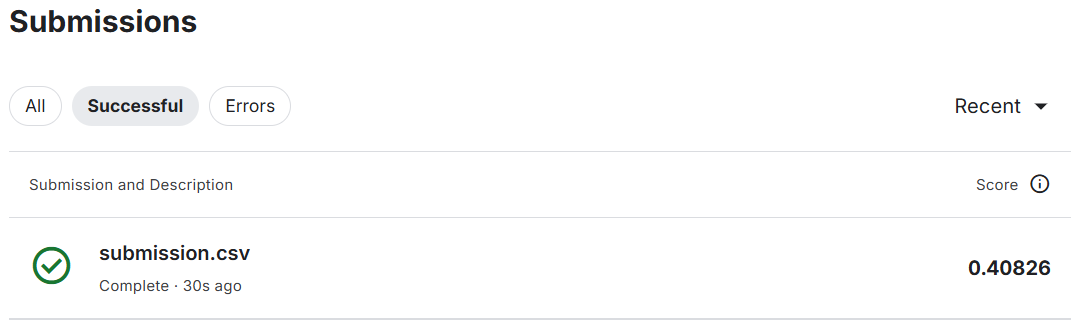

## 9. 오늘의 정리

- 이번 문제는 집의 여러 특징을 이용해 `SalePrice`를 예측하는 회귀 문제이다.
- 실제 데이터에는 숫자형, 범주형, 결측값 등 다양한 형태의 데이터가 존재한다.
- `Id`처럼 예측에 의미가 없는 feature는 제거할 수 있다.
- 숫자형 feature는 평균 0, 표준편차 1에 가깝게 표준화한다.
- 숫자형 결측값은 평균값에 해당하도록 처리할 수 있다.
- 문자열 범주형 데이터는 One-Hot Encoding으로 숫자로 변환한다.
- 집값은 절대 오차보다 상대적인 오차가 중요하기 때문에 `log(SalePrice)`를 사용할 수 있다.
- 모델은 `nn.Linear(feature_count, 1)`과 같은 단순한 회귀 모델부터 baseline으로 시작할 수 있다.
- K-Fold Cross Validation은 데이터를 여러 방식으로 나누어 모델의 일반화 성능을 더 안정적으로 확인하는 방법이다.
- Train Loss만 낮다고 좋은 모델이 아니다. Validation Loss와 함께 확인해야 한다.
- 여러 Fold에서 학습한 모델의 예측을 평균내 Ensemble할 수 있다.
- log 가격을 예측했다면 최종 제출 전에 `exp()`를 사용해 원래 집값으로 되돌린다.